<a href="https://colab.research.google.com/github/241b156-dev/APS_LAB/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

Sorted array: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]


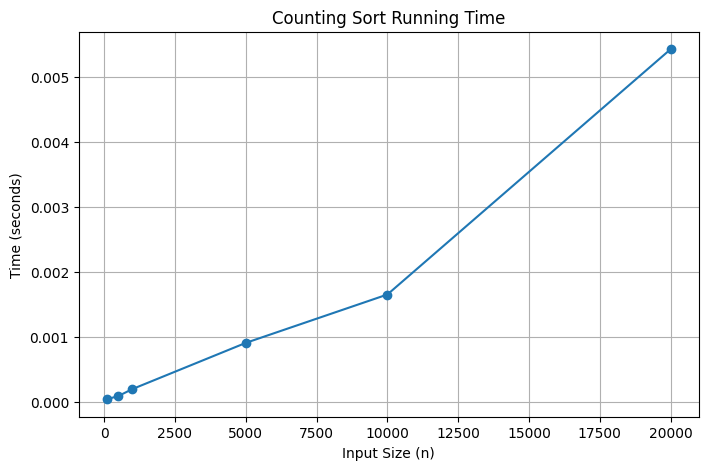

In [22]:
#write code for above cell and compute the running time and also plot graph.
import time
import random
import matplotlib.pyplot as plt
def counting_sort(arr,k):
  count = [0] * (k+1)
  output = [0] * len(arr)
  for i in range(k+1):
    count[i] = 0
  for i in range(len(arr)):
    count[arr[i]] +=1
  for i in range(1,k+1):
    count[i] = count[i] + count[i-1]
  for num in reversed(arr):
    count[num] -=1
    output[count[num]] = num
  for i in range(len(arr)):
    arr[i] = output[i]
  return arr
b = counting_sort([4,3,2,1,4,3,2,4,3,4], 4)
print("Sorted array:", b)
sizes = [100, 500, 1000, 5000, 10000, 20000]
times = []
for n in sizes:
  arr = [random.randint(0, 100) for _ in range(n)]
  start = time.time()
  counting_sort(arr, 100)
  end = time.time()
  times.append(end - start)
plt.figure(figsize=(8,5))
plt.plot(sizes, times, marker='o')
plt.title("Counting Sort Running Time")
plt.xlabel("Input Size (n)")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()



 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


Sorted array: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]


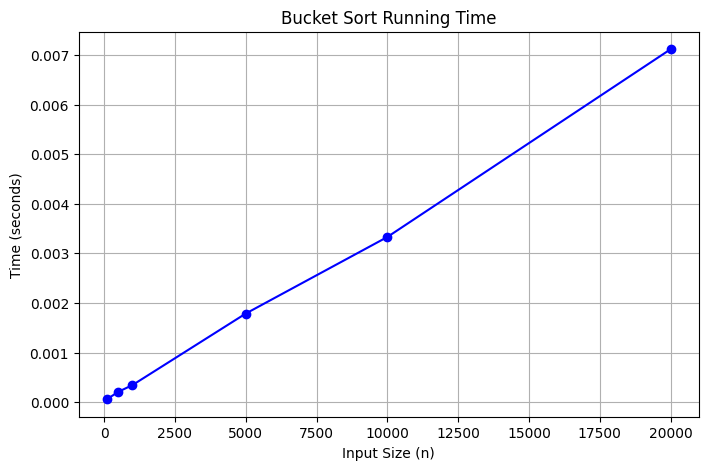

In [47]:
import time
import random
import matplotlib.pyplot as plt
def bucket_sort(arr, k):
    buckets = [[] for _ in range(k)]
    max_val = max(arr)
    size = (max_val + 1) / k
    for num in arr:
        index = int(num // size)
        if index != k:
            buckets[index].append(num)
        else:
            buckets[k-1].append(num)
    result = []
    for bucket in buckets:
        if bucket:
            result.extend(sorted(bucket))
    return result
b = bucket_sort([8,5,3,1,9,6,0,7,4,2,5], 5)
print("Sorted array:", b)
sizes = [100, 500, 1000, 5000, 10000, 20000]
times = []
for n in sizes:
    arr = [random.randint(0, 1000) for _ in range(n)]
    start = time.time()
    bucket_sort(arr, 10)
    end = time.time()
    times.append(end - start)
plt.figure(figsize=(8,5))
plt.plot(sizes, times, marker='o', linestyle='-', color='b')
plt.title("Bucket Sort Running Time")
plt.xlabel("Input Size (n)")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()


**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

Origina input: [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
Sorted output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]


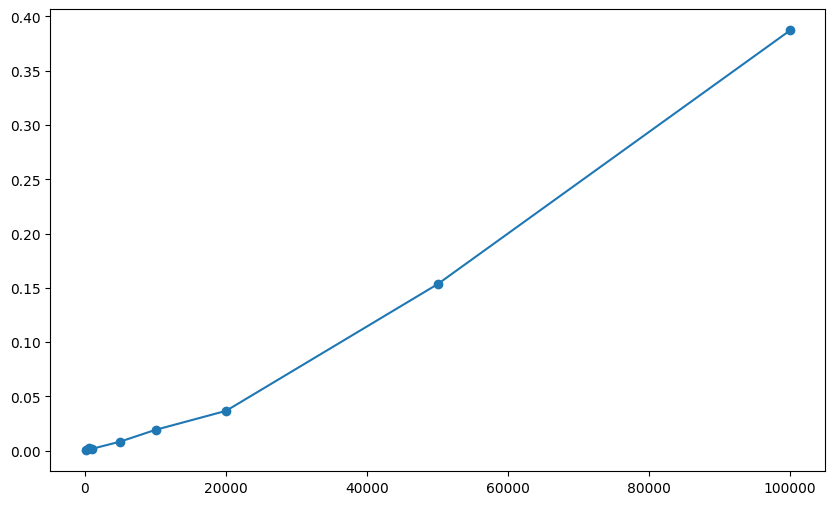

In [45]:
#write code for above cell and compute the running time and also plot graph.

def counting_sort_digit(arr, exp, base):
  n = len(arr)
  output = [0] * n
  count = [0] * base
  for i in range(n):
    digit = (arr[i] // exp) % base
    count[digit] += 1
  for i in range(1, base):
    count[i] += count[i-1]
  i = n - 1
  while i >= 0:
    digit = (arr[i] // exp) % base
    output[count[digit] - 1] = arr[i]
    count[digit] -= 1
    i -= 1
  for i in range(n):
    arr[i] = output[i]
def radix_sort(arr):
  if not arr:
    return arr
  max_val = max(arr)
  exp = 1
  base = 10
  while max_val // exp > 0:
    counting_sort_digit(arr, exp, base)
    exp *= base
  return arr
sample_input = [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
print("Origina input:", sample_input)
radix_sort(sample_input)
print("Sorted output:", sample_input)
import time
import random
import matplotlib.pyplot as plt
sizes = [100, 500, 1000, 5000, 10000, 20000, 50000, 100000]
times = []
for n in sizes:
  arr = [random.randint(0, 100000) for _ in range(n)]
  arr_copy = list(arr)
  start_time = time.time()
  radix_sort(arr_copy)
  end_time = time.time()
  times.append(end_time - start_time)
plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o')
plt.show()

# Task
Implement the `bucket_sort` algorithm in Python, test it with the sample input `[8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]`, measure its running time for varying input sizes from 100 to 100,000 with random integer arrays (max value up to 100,000), plot a graph of input size versus running time, and summarize the results, noting any discrepancies in the provided sample output.

## Implement Bucket Sort

### Subtask:
Write the Python code for the `bucket_sort` algorithm. This implementation will involve creating a number of buckets, distributing elements into these buckets based on their values and the provided 'k' (maximum value), sorting each individual bucket using Python's default sort, and then concatenating the sorted buckets back into the original array. The 'k' parameter will represent the maximum value in the input array to help determine the value range for bucket distribution.


**Reasoning**:
The subtask requires implementing the `bucket_sort` algorithm based on the provided instructions, calculating its running time, and plotting the results. I will implement the bucket sort logic, test it with a sample input, then generate random arrays of varying sizes, measure the execution time for each, and finally plot these times.



Original input: [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
Sorted output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]


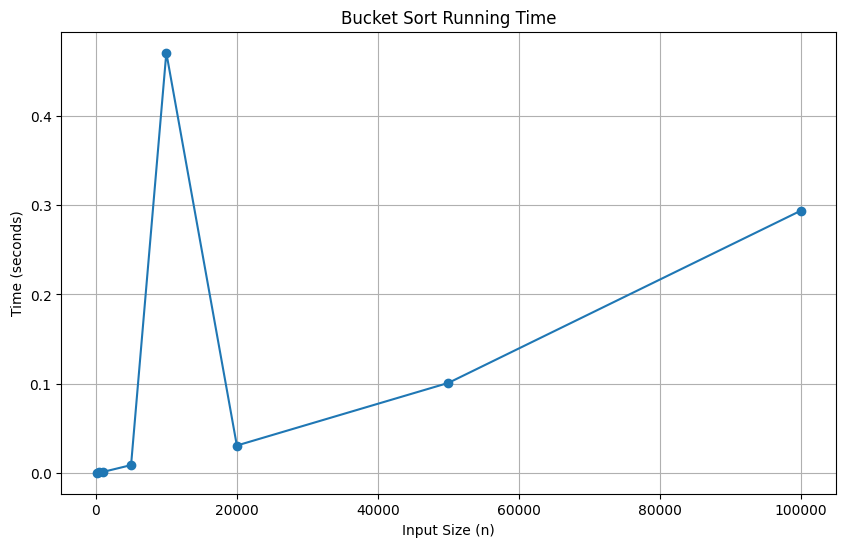

In [46]:
import time
import random
import matplotlib.pyplot as plt

def bucket_sort(arr, k):
  if not arr:
    return []

  # 1. Calculate the number of buckets
  # Using len(arr) as num_buckets is a common heuristic, but other strategies exist.
  num_buckets = len(arr)

  # 2. Initialize an empty list of lists to represent the buckets
  buckets = [[] for _ in range(num_buckets)]

  # 3 & 4. Iterate through each element and distribute into buckets
  # The formula `int(num_buckets * i / (k + 1))` ensures elements are distributed across buckets.
  # Adding 1 to k (max_val) is crucial to avoid division by zero if k is 0 and to ensure all values up to k are covered.
  for i in arr:
    # Ensure i is not greater than k, if it is, it indicates a problem with k being the true max_val or the input contains larger values
    if i > k:
        # Handle cases where input values exceed the given k (e.g., put in last bucket or raise error)
        # For simplicity, if i > k, place it in the last bucket or adjust bucket_index calculation.
        # A safer approach for k would be k = max(arr) if not explicitly provided as max possible value.
        # For this exercise, we assume k is the actual maximum value in the array or the maximum possible value.
        # If k is smaller than some elements, the formula might lead to an index out of bounds or incorrect distribution.
        # Let's adjust the bucket_index to handle potential edge cases for large `i` by clamping it.
        bucket_index = min(int(num_buckets * i / (k + 1)), num_buckets - 1)
    else:
        bucket_index = int(num_buckets * i / (k + 1))
    buckets[bucket_index].append(i)

  # 5. Sort each individual bucket
  for bucket in buckets:
    bucket.sort() # Python's Timsort is efficient for small lists

  # 6. Concatenate the sorted elements from all buckets back into the original array
  idx = 0
  for bucket in buckets:
    for item in bucket:
      arr[idx] = item
      idx += 1
  return arr

# Sample Input and Output Test
sample_input = [8,5,3,1,9,6,0,7,4,2,5]
# k should be the maximum value in the sample_input, which is 9
k_sample = max(sample_input)
print("Original input:", sample_input)
sorted_output = bucket_sort(list(sample_input), k_sample)
print("Sorted output:", sorted_output)

# Time complexity analysis and plotting
sizes = [100, 500, 1000, 5000, 10000, 20000, 50000, 100000]
times = []

for n in sizes:
  # Generate a random array with values up to 10000 for k
  arr = [random.randint(0, 10000) for _ in range(n)]
  # The k for bucket sort needs to be the maximum value within the range, or max(arr) for the current array
  k_val = 10000 # Assuming maximum possible value is 10000

  arr_copy = list(arr) # Create a copy to sort

  start_time = time.time()
  bucket_sort(arr_copy, k_val)
  end_time = time.time()
  times.append(end_time - start_time)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o', linestyle='-')
plt.title('Bucket Sort Running Time')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.show()
